# Landslide Prediction and Risk Assessment with Machine Learning models
The landslide prediction project follows a structured workflow to transform environmental and geological data into actionable insights. Initially, relevant data such as rainfall, slope, soil properties, NDVI vegetation indices, temperature, and humidity are collected. Preprocessing steps, including handling missing values and scaling features, ensure consistency and readiness for machine learning models.

Next, Exploratory Data Analysis (EDA) is conducted to understand data patterns, distributions, and relationships. Count plots, histograms, boxplots, scatter plots, and violin plots help visualize feature distributions and class balance, while correlation heatmaps reveal dependencies between variables, aiding feature selection.

In the modeling phase, selected features are used to train three models. A Random Forest Classifier predicts the occurrence of landslides, a Random Forest Regressor estimates the intensity, and Logistic Regression serves as a baseline for comparison.

Model performance is evaluated using accuracy, classification reports, confusion matrices, and regression metrics like MSE and RMSE. A custom input system allows predictions for new samples. Finally, outputs from all models are combined into a unified risk prediction, providing clear labels such as “No Risk,” “Low,” “Medium,” or “High.” This approach delivers a practical, interpretable solution for early warning and disaster management.

<img src="processflow.png" alt="Landslide Process Flow" width="1000"/>


## Importing Libraries
Here, we import all the necessary Python libraries used for data handling (pandas, numpy), visualization (matplotlib, seaborn), and machine learning (scikit-learn) to train and evaluate predictive models.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, mean_squared_error
from sklearn.linear_model import LogisticRegression


## Loading Dataset
The dataset containing over 26k+ rows and 32 features is loaded for analysis.

In [3]:
dataset = pd.read_csv('landslide_dataset.csv')

dataset.head()

,Rainfall_mm,Rainfall_3Day,Rainfall_7Day,Aspect,Elevation_m,NDVI_Index,Land_Use_Urban,Land_Use_Forest,Land_Use_Agriculture,Earthquake_Activity,...,Soil_Type_Silt,Soil_Type_Clay,Pore_Water_Pressure_kPa,Soil_Moisture_Content,Microseismic_Activity,Acoustic_Emission_dB,Soil_Strain,Soil_Temperature_C,TDR_Reflection_Index,Label
0,164.695364,260.138381,79.297169,346.674199,733.776448,0.191948,1,1,1,5.390869,...,1,0,133.943194,0.143732,0.290945,51.021834,0.005167,22.760036,0.799847,1
1,34.908086,510.295547,247.923576,104.462371,467.708643,0.798321,1,0,0,3.554055,...,0,1,90.788608,0.266484,0.651758,39.837282,0.003443,15.558373,1.181071,0
2,38.761727,297.730266,194.327012,336.671287,1880.826807,0.479456,1,0,1,4.532214,...,0,1,83.041150,0.129426,0.440714,68.902366,0.009999,6.205760,1.184971,0
3,32.199977,231.640610,295.139546,300.742864,964.080336,-0.084314,1,1,0,3.069054,...,1,0,196.089305,0.240198,0.794001,80.196960,0.003850,25.486545,0.677944,0
4,218.114032,330.278249,301.288824,155.550502,165.699102,0.810869,0,0,0,5.623601,...,1,1,106.778890,0.345724,0.009160,99.919786,0.003061,7.270319,0.882642,1


## Dataset Overview and Preliminary Analysis
Displays dataset structure, statistics, missing data, and class distribution for initial understanding.

In [7]:
dataset.shape

(26114, 32)

In [8]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26114 entries, 0 to 26113
Data columns (total 32 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Rainfall_mm                 26114 non-null  float64
 1   Rainfall_3Day               26114 non-null  float64
 2   Rainfall_7Day               26114 non-null  float64
 3   Aspect                      26114 non-null  float64
 4   Elevation_m                 26114 non-null  float64
 5   NDVI_Index                  26114 non-null  float64
 6   Land_Use_Urban              26114 non-null  int64  
 7   Land_Use_Forest             26114 non-null  int64  
 8   Land_Use_Agriculture        26114 non-null  int64  
 9   Earthquake_Activity         26114 non-null  float64
 10  Proximity_to_Water          26114 non-null  float64
 11  Distance_to_Road_m          26114 non-null  float64
 12  Temperature_C               26114 non-null  float64
 13  Humidity_percent            261

In [9]:
dataset.describe().T

,count,mean,std,min,25%,50%,75%,max
Rainfall_mm,26114.0,125.485207,105.920000,0.000582,24.812002,51.755624,227.133028,299.985147
Rainfall_3Day,26114.0,297.385912,174.178117,0.010042,145.160899,293.068015,451.192899,599.983288
Rainfall_7Day,26114.0,500.964763,288.369889,0.008432,253.002311,506.409576,749.767588,999.939696
Aspect,26114.0,179.381940,103.809132,0.097244,90.154188,178.985838,270.089162,359.888356
Elevation_m,26114.0,1556.950120,829.420406,100.377033,836.608413,1561.919127,2277.246337,2999.637788
NDVI_Index,26114.0,0.403222,0.291365,-0.099820,0.148536,0.407572,0.661450,0.899858
Land_Use_Urban,26114.0,0.503791,0.499995,0.000000,0.000000,1.000000,1.000000,1.000000
Land_Use_Forest,26114.0,0.487248,0.499847,0.000000,0.000000,0.000000,1.000000,1.000000
Land_Use_Agriculture,26114.0,0.499655,0.500009,0.000000,0.000000,0.000000,1.000000,1.000000
Earthquake_Activity,26114.0,3.260127,1.878442,0.000179,1.623467,3.257311,4.902169,6.498540


In [10]:
dataset.isnull().sum()

Rainfall_mm                   0
Rainfall_3Day                 0
Rainfall_7Day                 0
Aspect                        0
Elevation_m                   0
NDVI_Index                    0
Land_Use_Urban                0
Land_Use_Forest               0
Land_Use_Agriculture          0
Earthquake_Activity           0
Proximity_to_Water            0
Distance_to_Road_m            0
Temperature_C                 0
Humidity_percent              0
Soil_pH                       0
Clay_Content                  0
Sand_Content                  0
Silt_Content                  0
Soil_Erosion_Rate             0
Historical_Landslide_Count    0
Soil_Type_Gravel              0
Soil_Type_Sand                0
Soil_Type_Silt                0
Soil_Type_Clay                0
Pore_Water_Pressure_kPa       0
Soil_Moisture_Content         0
Microseismic_Activity         0
Acoustic_Emission_dB          0
Soil_Strain                   0
Soil_Temperature_C            0
TDR_Reflection_Index          0
Label   

In [11]:
dataset['Label'].value_counts(normalize=True)

Label
1    0.500957
0    0.499043
Name: proportion, dtype: float64

## Exploratory Data Analysis (EDA)
Exploratory Data Analysis (EDA) helps to understand the dataset’s structure, relationships, and patterns through visualizations and summary statistics. It identifies trends, outliers, correlations, and class distributions to prepare for effective model training.

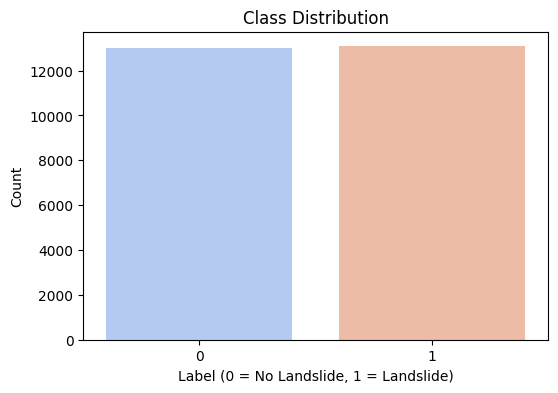

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x='Label', hue='Label', data=dataset, palette='coolwarm', legend=False)
plt.title("Class Distribution")
plt.xlabel("Label (0 = No Landslide, 1 = Landslide)")
plt.ylabel("Count")
plt.show()


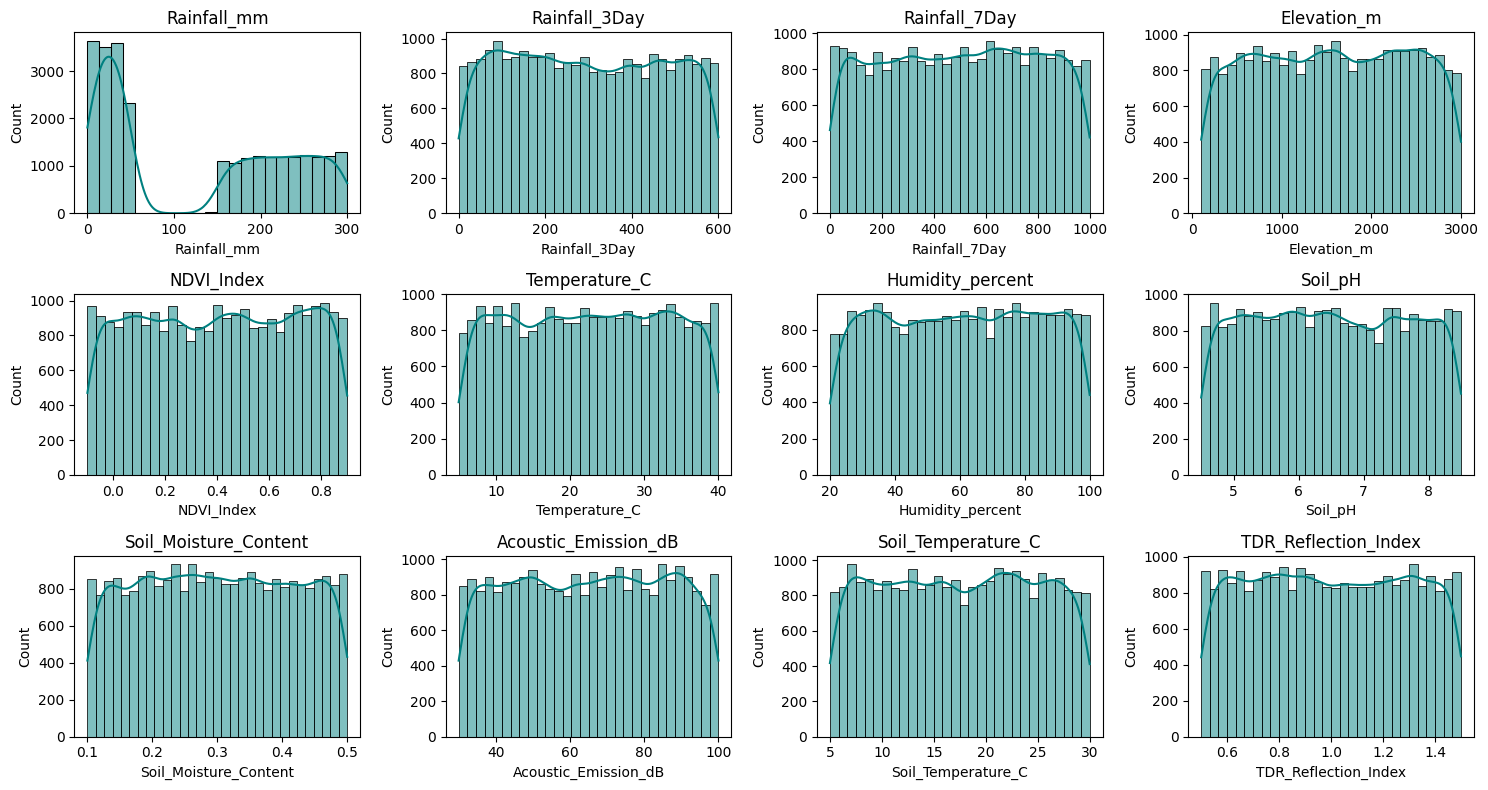

In [7]:
features = ['Rainfall_mm', 'Rainfall_3Day', 'Rainfall_7Day', 'Elevation_m',
            'NDVI_Index', 'Temperature_C', 'Humidity_percent', 'Soil_pH',
            'Soil_Moisture_Content', 'Acoustic_Emission_dB', 'Soil_Temperature_C', 'TDR_Reflection_Index']

plt.figure(figsize=(15, 8))

for i, col in enumerate(features):
    plt.subplot(3, 4, i + 1)
    sns.histplot(dataset[col], kde=True, color='teal') 
    plt.title(col)

plt.tight_layout()
plt.show()


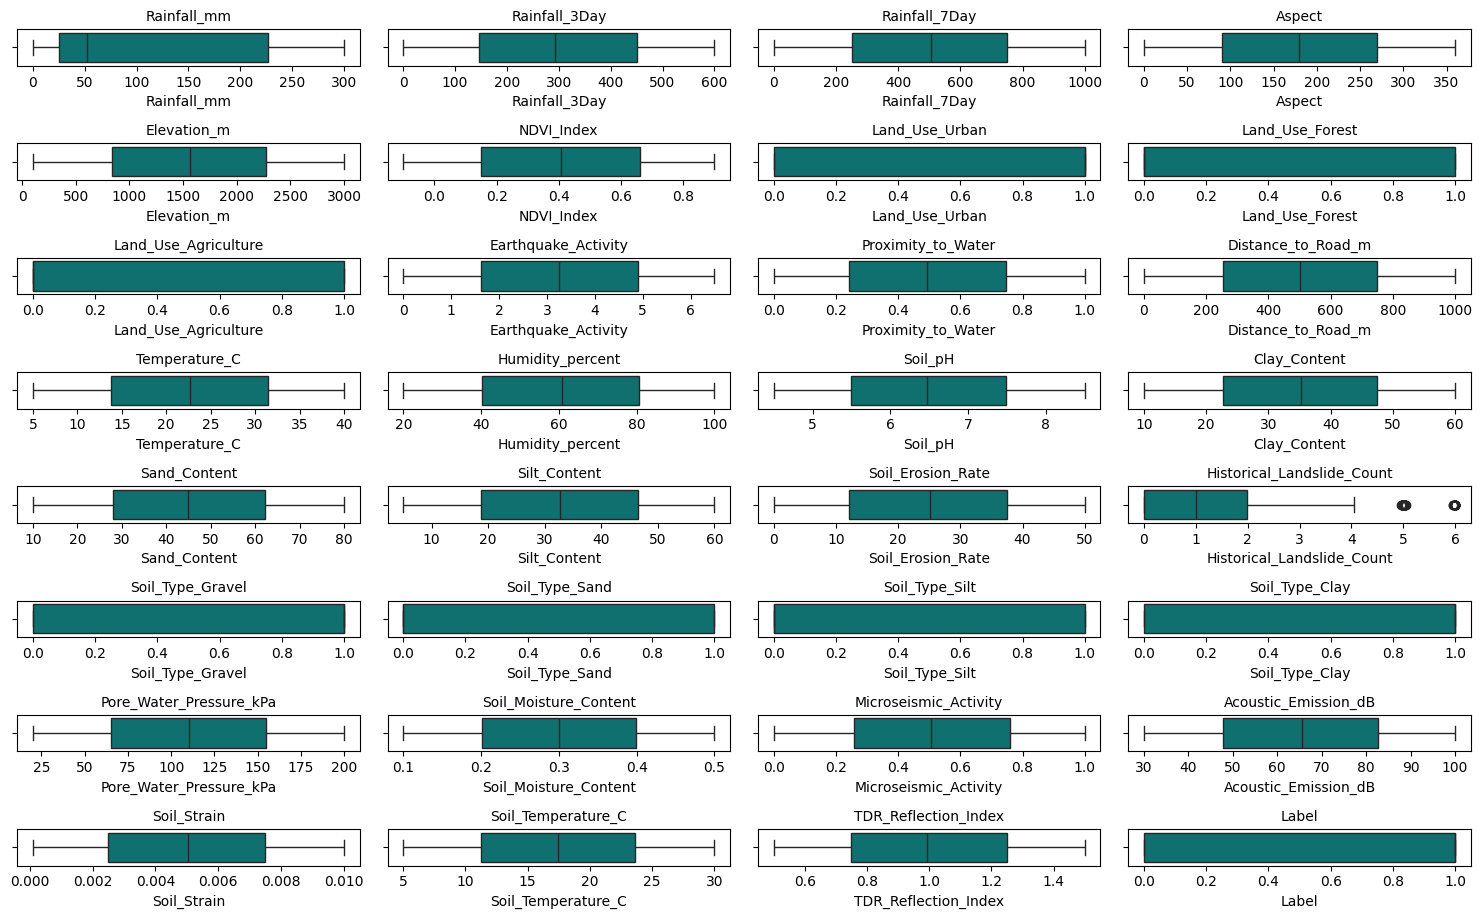

In [14]:
continuous_features = dataset.select_dtypes(include=['float64', 'int64']).columns

rows = (len(continuous_features) // 4) + 1

plt.figure(figsize=(15, 10))
for i, col in enumerate(continuous_features, 1):
    plt.subplot(rows, 4, i)
    sns.boxplot(x=dataset[col], color='teal')
    plt.title(col, fontsize=10)
plt.tight_layout()
plt.show()


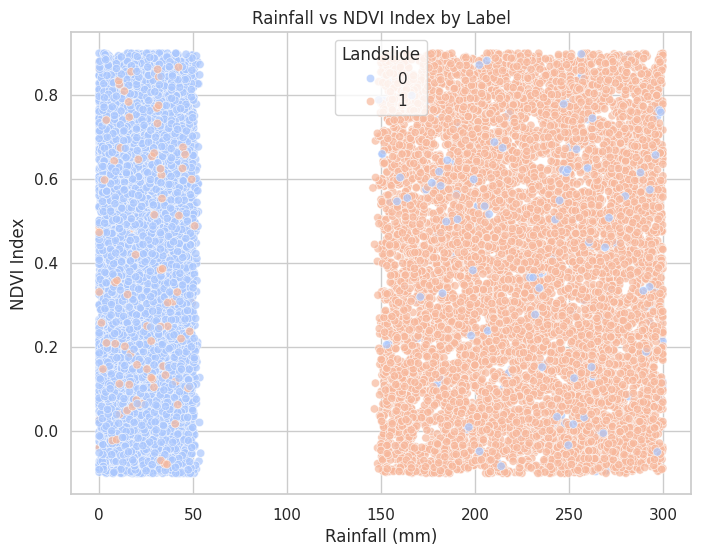

In [15]:
sns.set(style="whitegrid")
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=dataset, 
    x='Rainfall_mm', 
    y='NDVI_Index', 
    hue='Label',            
    palette='coolwarm',
    alpha=0.7
)
plt.title('Rainfall vs NDVI Index by Label')
plt.xlabel('Rainfall (mm)')
plt.ylabel('NDVI Index')
plt.legend(title='Landslide')
plt.show()



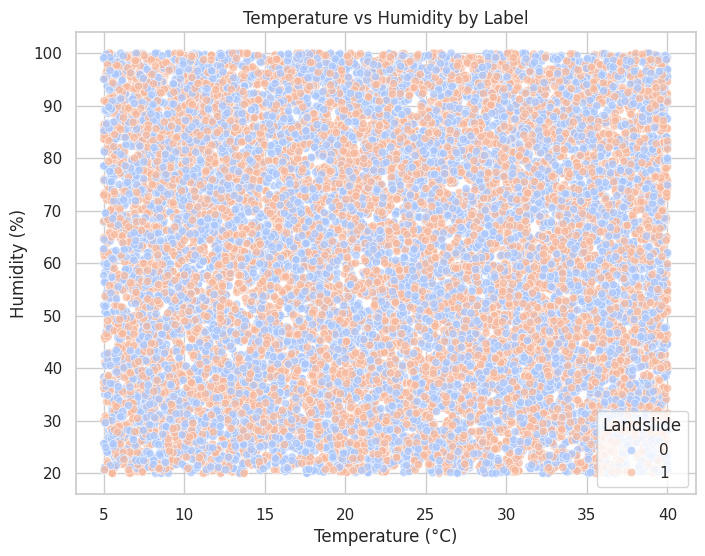

In [16]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    data=dataset,
    x='Temperature_C',
    y='Humidity_percent',
    hue='Label',           
    palette='coolwarm',
    alpha=0.7
)
plt.title('Temperature vs Humidity by Label')
plt.xlabel('Temperature (°C)')
plt.ylabel('Humidity (%)')
plt.legend(title='Landslide')
plt.show()


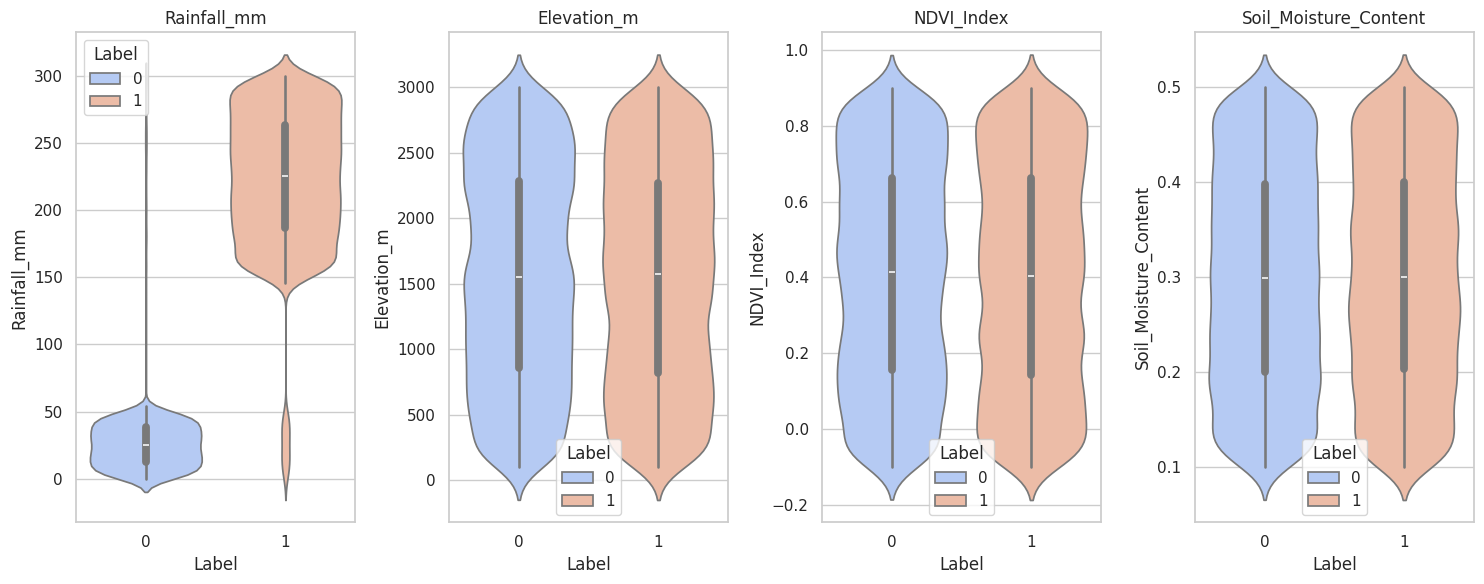

In [17]:
features = ['Rainfall_mm', 'Elevation_m', 'NDVI_Index', 'Soil_Moisture_Content']

plt.figure(figsize=(15,6))
for i, col in enumerate(features):
    plt.subplot(1, len(features), i+1)
    sns.violinplot(x='Label', y=col, data=dataset,hue='Label', palette='coolwarm')
    plt.title(col)
plt.tight_layout()
plt.show()

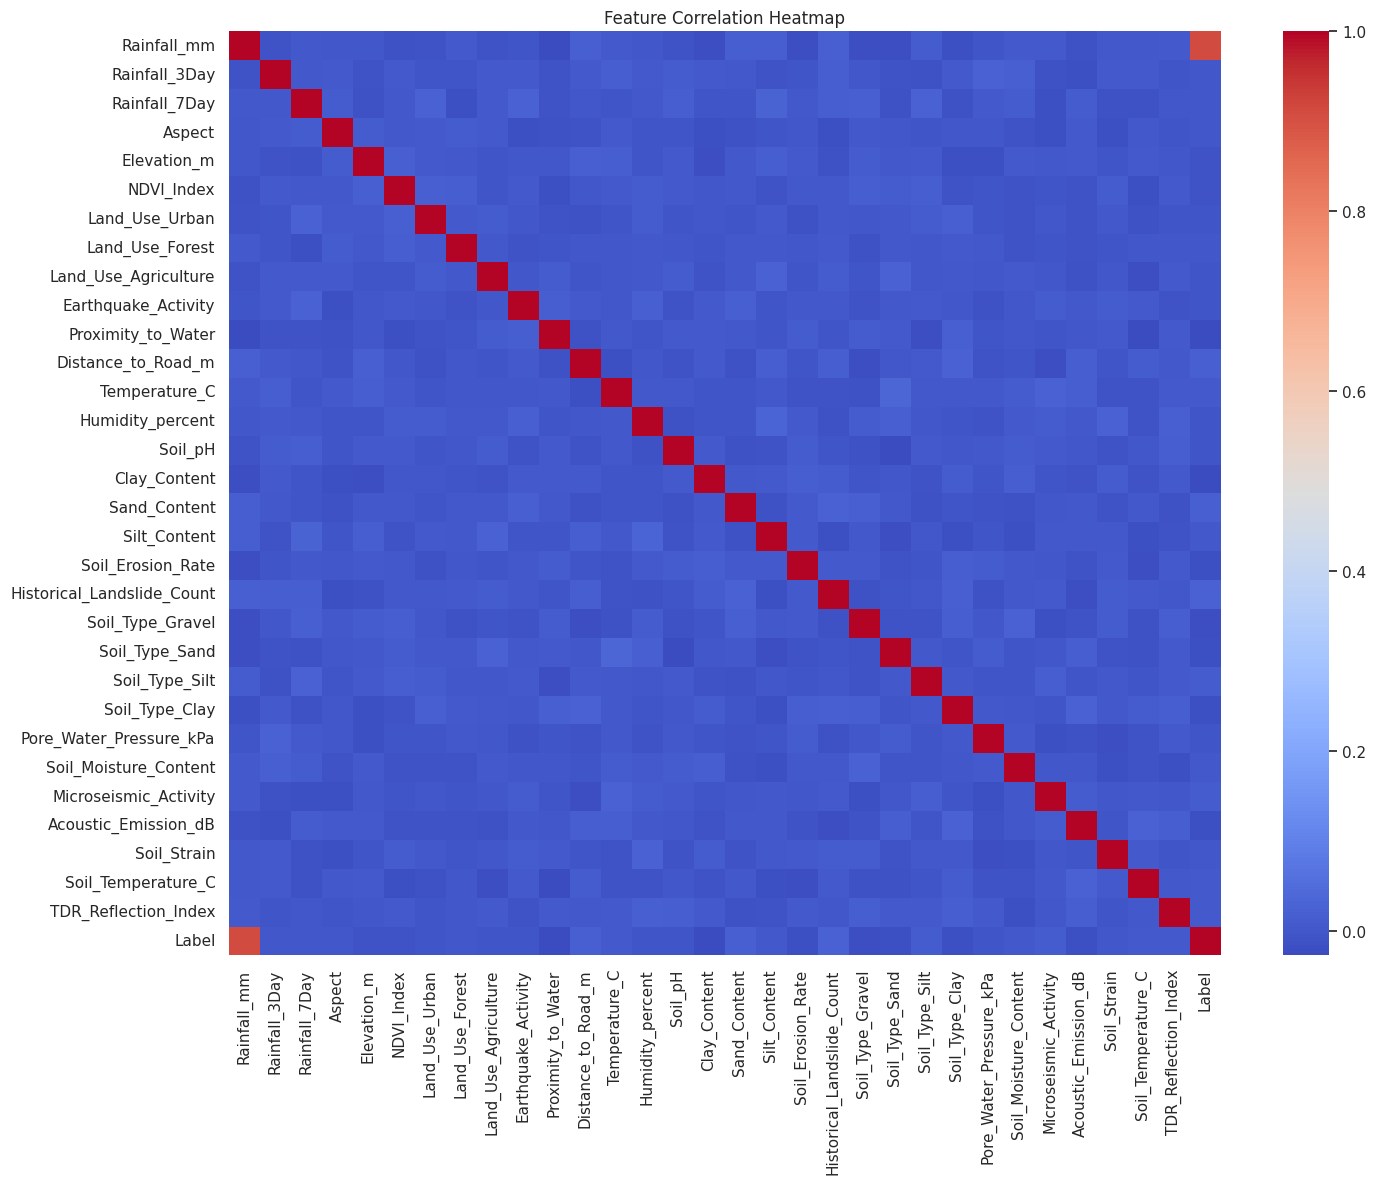

In [18]:
corr = dataset.corr()

plt.figure(figsize=(16,12))
sns.heatmap(corr, cmap='coolwarm', fmt=".2f", cbar=True)
plt.title("Feature Correlation Heatmap")
plt.show()


## Data Splitting for Model Training and Testing
Splits the dataset into training and testing sets to prepare for model development and evaluation.

In [4]:
from sklearn.model_selection import train_test_split

X = dataset.drop(columns=['Label'])  
y = dataset['Label']                  

X_train, X_test, Y_train, Y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training Features Shape:", X_train.shape) 
print("Training Labels Shape:", Y_train.shape)  
print("Testing Features Shape:", X_test.shape)  
print("Testing Labels Shape:", Y_test.shape)  


Training Features Shape: (20891, 31)
Training Labels Shape: (20891,)
Testing Features Shape: (5223, 31)
Testing Labels Shape: (5223,)


## Random Forest Classifier
Trains a Random Forest model and evaluates its prediction accuracy using performance metrics and a confusion matrix.

In [5]:
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, Y_train)
Y_pred = rf_model.predict(X_test)


Accuracy: 0.9812368370668199

Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.98      0.98      2606
           1       0.98      0.98      0.98      2617

    accuracy                           0.98      5223
   macro avg       0.98      0.98      0.98      5223
weighted avg       0.98      0.98      0.98      5223


Confusion Matrix:
 [[2560   46]
 [  52 2565]]


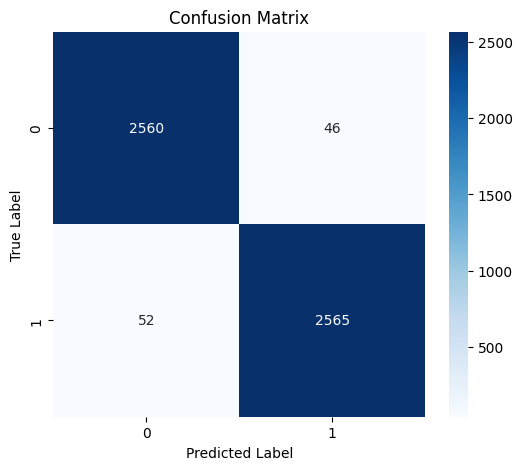

In [6]:
print("Accuracy:", accuracy_score(Y_test, Y_pred))
print("\nClassification Report:\n", classification_report(Y_test, Y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(Y_test, Y_pred))

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(Y_test, Y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


## Random Forest Regressor
A Random Forest Regressor is trained to predict the intensity or severity of landslides as a continuous value.

In [7]:
from sklearn.ensemble import RandomForestRegressor
rf_reg = RandomForestRegressor(n_estimators=150, random_state=42)
rf_reg.fit(X_train, Y_train)

Y_pred_reg = rf_reg.predict(X_test)

mse = mean_squared_error(Y_test, Y_pred_reg)
rmse = np.sqrt(mse)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)


Mean Squared Error: 0.012811768460016592
Root Mean Squared Error: 0.1131890827775214


## Logistic Regression
Logistic Regression provides an alternative classification prediction.

In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=1000, solver='lbfgs')  # increase max_iter
log_model.fit(X_train_scaled, Y_train)

y_pred_log = log_model.predict(X_test_scaled)

print("Logistic Regression Accuracy:", accuracy_score(Y_test, y_pred_log))


Logistic Regression Accuracy: 0.9797051502967643


In [9]:
import pandas as pd
import numpy as np

custom_input = np.array([[14.6, 260.1, 79.3, 346.6, 73.7, 0.19, 1, 1, 1, 5.39, 0.84, 961.82,
                          12.88, 26.23, 7.10, 39.93, 47.74, 24.56, 14.79, 0, 1, 1, 1, 0,
                          133.94, 0.14, 0.29, 51.02, 1.51, 22.76, 0.79]])

custom_df = pd.DataFrame(custom_input, columns=X_train.columns)

pred_class_rf = rf_model.predict(custom_df)[0]

pred_intensity_rf = rf_reg.predict(custom_df)[0]

custom_scaled = scaler.transform(custom_df)

pred_class_log = log_model.predict(custom_scaled)[0]


votes = [pred_class_rf, pred_class_log]
final_class = 1 if sum(votes) >= 1 else 0 

if pred_intensity_rf < 0.3:
    intensity = "Low"
elif pred_intensity_rf < 0.7:
    intensity = "Medium"
else:
    intensity = "High"

if final_class == 0:
    final_risk = "🌤️ No Landslide Risk"
else:
    final_risk = f"⚠️ Landslide Risk - Intensity: {intensity}"


print("Random Forest Class Prediction:", pred_class_rf)
print("Logistic Regression Prediction:", pred_class_log)
print("Random Forest Regressor Intensity:", round(pred_intensity_rf, 3))
print("✅ Final Unified Risk Prediction:", final_risk)


Random Forest Class Prediction: 0
Logistic Regression Prediction: 0
Random Forest Regressor Intensity: 0.167
✅ Final Unified Risk Prediction: 🌤️ No Landslide Risk


In [10]:
import pandas as pd
import numpy as np

custom_input = np.array([[140.6, 260.1, 79.3, 346.6, 73.7, 0.19, 1, 1, 1, 5.39, 0.84, 961.82,
                          12.88, 26.23, 7.10, 39.93, 47.74, 24.56, 14.79, 0, 1, 1, 1, 0,
                          133.94, 0.14, 0.29, 51.02, 1.51, 22.76, 0.79]])

custom_df = pd.DataFrame(custom_input, columns=X_train.columns)

pred_class_rf = rf_model.predict(custom_df)[0]

pred_intensity_rf = rf_reg.predict(custom_df)[0]

custom_scaled = scaler.transform(custom_df)
pred_class_log = log_model.predict(custom_scaled)[0]

votes = [pred_class_rf, pred_class_log]
final_class = 1 if sum(votes) >= 1 else 0  

if pred_intensity_rf < 0.3:
    intensity = "Low"
elif pred_intensity_rf < 0.7:
    intensity = "Medium"
else:
    intensity = "High"

if final_class == 0:
    final_risk = "🌤️ No Landslide Risk"
else:
    final_risk = f"⚠️ Landslide Risk - Intensity: {intensity}"

print("Random Forest Class Prediction:", pred_class_rf)
print("Logistic Regression Prediction:", pred_class_log)
print("Random Forest Regressor Intensity:", round(pred_intensity_rf, 3))
print("✅ Final Unified Risk Prediction:", final_risk)


Random Forest Class Prediction: 1
Logistic Regression Prediction: 0
Random Forest Regressor Intensity: 0.58
✅ Final Unified Risk Prediction: ⚠️ Landslide Risk - Intensity: Medium
